Libraries loaded.
Raw data shape : (110000, 15)
Columns        : ['prodId', 'prodName', 'catId', 'catName', 'min(rank)', 'catLevel', 'wholeCategoryName', 'naver_catName_depth1', 'naver_catId_depth1', 'naver_catName_depth2', 'naver_catId_depth2', 'naver_catName_depth3', 'naver_catId_depth3', 'naver_catName_depth4', 'naver_catId_depth4']
Working columns : ['prod_name', 'category']
Unique categories (11) :
가구/인테리어    10000
도서         10000
디지털/가전     10000
생활/건강      10000
스포츠/레저     10000
식품         10000
여가/생활편의    10000
출산/육아      10000
패션의류       10000
패션잡화       10000
화장품/미용     10000
Name: category, dtype: int64
Sample before/after cleaning:
  BEFORE: 한옥 네모 수반 화병
  AFTER : 한옥 네모 수반 화병

  BEFORE: 카브 모던앞치마 박시핏 2컬러 브라운
  AFTER : 카브 모던앞치마 박시핏 2컬러 브라운

  BEFORE: 우리 미니멀 러그 사계절 플라워카페트 발닦개 싱크대 빨아쓰는 스마일발매트
  AFTER : 우리 미니멀 러그 사계절 플라워카페트 발닦개 싱크대 빨아쓰는 스마일발매트

  BEFORE: 모던 블루 러그 물고기 카펫 잉어 금붕어 바다 러그
  AFTER : 모던 블루 러그 물고기 카펫 잉어 금붕어 바다 러그

  BEFORE: 고밀도 쟈스민 레이스 패드세트Q/운현궁
  AFTER : 고밀도 쟈스민 레이스 패드세

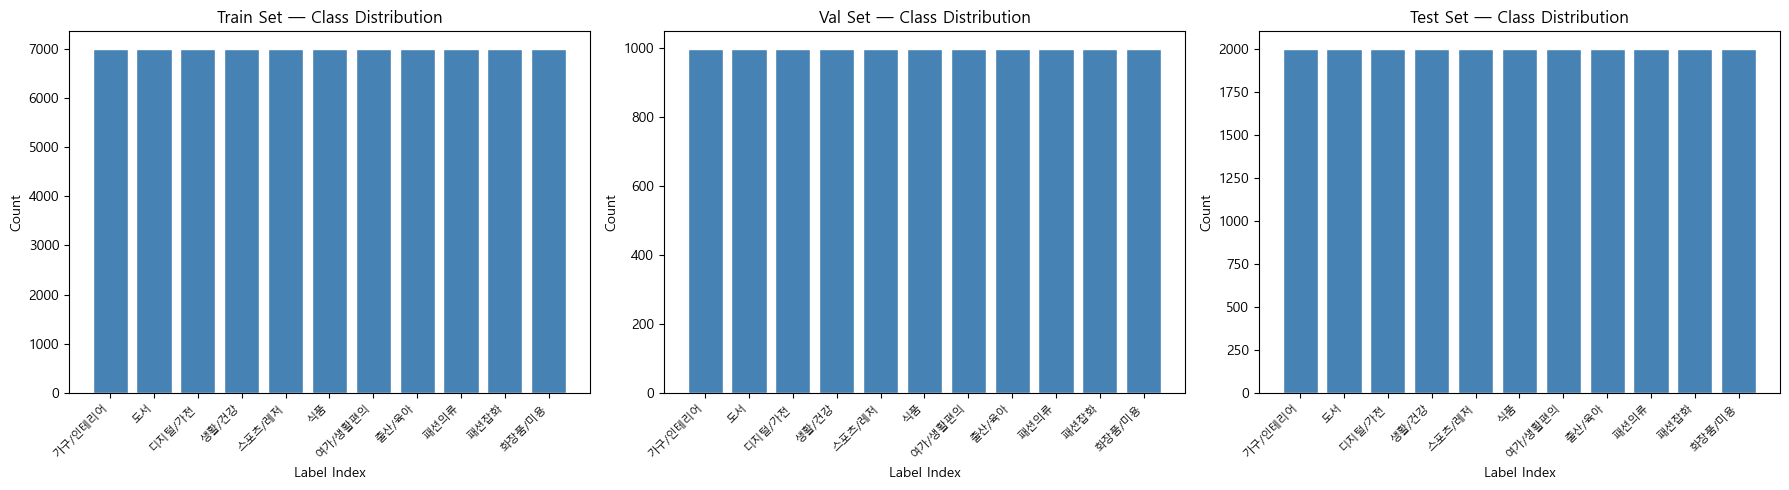

Saved → data/split_distribution.png
PREPROCESSING SUMMARY
  Total records (after cleaning) : 109,995
  Number of classes              : 11
  Train / Val / Test             : 76,996 / 10,988 / 22,011
  Avg. product name length       : 32.1 chars
  Label encoder                  : data/label_encoder.pkl
Next → 02_stage1_model_comparison.ipynb


In [2]:
# =============================================================
# 01_preprocessing.ipynb
# Data Preprocessing for Seller Segmentation Framework
# -------------------------------------------------------------
# Input : 네이버_실험용샘플_1dep.csv
# Output: data/train.csv, data/val.csv, data/test.csv
#         data/label_encoder.pkl
# =============================================================

# ── Cell 1: Imports ──────────────────────────────────────────
import pandas as pd
import numpy as np
import re
import pickle
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import os

plt.rcParams['font.family'] = 'Malgun Gothic'  # Windows
# plt.rcParams['font.family'] = 'AppleGothic'  # Mac
plt.rcParams['axes.unicode_minus'] = False
os.makedirs('data', exist_ok=True)

print("Libraries loaded.")


# ── Cell 2: Load Raw Data ────────────────────────────────────
df = pd.read_csv('네이버_실험용샘플_1dep.csv', encoding='utf-8')
# df = pd.read_csv('네이버_실험용샘플_1dep.csv', encoding='cp949')

print(f"Raw data shape : {df.shape}")
print(f"Columns        : {df.columns.tolist()}")


# ── Cell 3: Select Required Columns ─────────────────────────
# Keep only columns needed for the framework
PROD_COL  = 'prodName'              # product name (feature)
LABEL_COL = 'naver_catName_depth1'  # depth-1 category (target)

df = df[[PROD_COL, LABEL_COL]].copy()
df.columns = ['prod_name', 'category']

print(f"Working columns : {df.columns.tolist()}")
print(f"Unique categories ({df['category'].nunique()}) :")
print(df['category'].value_counts())


# ── Cell 4: Text Cleaning ────────────────────────────────────
def clean_text(text: str) -> str:
    """
    Normalize product name text.
    Steps:
      1. Remove excessive whitespace
      2. Remove special characters except Korean, English, digits
      3. Strip leading/trailing whitespace
    """
    text = str(text)
    text = re.sub(r'\s+', ' ', text)                  # collapse whitespace
    text = re.sub(r'[^\w\s가-힣a-zA-Z0-9]', ' ', text)  # keep alphanum + Korean
    text = text.strip()
    return text

df['prod_name_clean'] = df['prod_name'].apply(clean_text)

# Verify cleaning
print("Sample before/after cleaning:")
for orig, cleaned in zip(df['prod_name'].head(5), df['prod_name_clean'].head(5)):
    print(f"  BEFORE: {orig}")
    print(f"  AFTER : {cleaned}\n")


# ── Cell 5: Remove Empty / Too-Short Texts ───────────────────
MIN_CHARS = 2   # minimum character length after cleaning

before = len(df)
df = df[df['prod_name_clean'].str.len() >= MIN_CHARS].reset_index(drop=True)
after = len(df)

print(f"Removed {before - after} records with text length < {MIN_CHARS}")
print(f"Remaining records: {after:,}")


# ── Cell 6: Label Encoding ───────────────────────────────────
le = LabelEncoder()
df['label'] = le.fit_transform(df['category'])

label_map = dict(zip(le.classes_, le.transform(le.classes_)))
print("\nLabel mapping:")
for cat, idx in sorted(label_map.items(), key=lambda x: x[1]):
    print(f"  {idx:2d} | {cat}")

# Save encoder for inference
with open('data/label_encoder.pkl', 'wb') as f:
    pickle.dump(le, f)
print("\nLabel encoder saved → data/label_encoder.pkl")


# ── Cell 7: Train / Val / Test Split (70 / 10 / 20) ─────────
# Stratified split to maintain class balance
X = df['prod_name_clean'].values
y = df['label'].values

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.667, random_state=42, stratify=y_temp
)
# 0.667 of 0.30 ≈ 0.20  →  final split: 70 / 10 / 20

print(f"Train : {len(X_train):>7,}  ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val   : {len(X_val):>7,}  ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test  : {len(X_test):>7,}  ({len(X_test)/len(X)*100:.1f}%)")


# ── Cell 8: Save Split Data ──────────────────────────────────
train_df = pd.DataFrame({'prod_name': X_train, 'label': y_train})
val_df   = pd.DataFrame({'prod_name': X_val,   'label': y_val})
test_df  = pd.DataFrame({'prod_name': X_test,  'label': y_test})

train_df.to_csv('data/train.csv', index=False, encoding='utf-8-sig')
val_df.to_csv('data/val.csv',     index=False, encoding='utf-8-sig')
test_df.to_csv('data/test.csv',   index=False, encoding='utf-8-sig')

print("Saved:")
print("  data/train.csv")
print("  data/val.csv")
print("  data/test.csv")


# ── Cell 9: Class Distribution Verification ─────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
splits = [('Train', train_df), ('Val', val_df), ('Test', test_df)]

for ax, (name, split_df) in zip(axes, splits):
    counts = split_df['label'].value_counts().sort_index()
    ax.bar(range(len(counts)), counts.values, color='steelblue', edgecolor='white')
    ax.set_title(f'{name} Set — Class Distribution')
    ax.set_xlabel('Label Index')
    ax.set_ylabel('Count')
    ax.set_xticks(range(len(counts)))
    ax.set_xticklabels(le.classes_, rotation=45, ha='right', fontsize=8)

plt.tight_layout()
plt.savefig('data/split_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved → data/split_distribution.png")


# ── Cell 10: Summary ─────────────────────────────────────────
print("=" * 55)
print("PREPROCESSING SUMMARY")
print("=" * 55)
print(f"  Total records (after cleaning) : {len(df):,}")
print(f"  Number of classes              : {df['category'].nunique()}")
print(f"  Train / Val / Test             : {len(train_df):,} / {len(val_df):,} / {len(test_df):,}")
print(f"  Avg. product name length       : {df['prod_name_clean'].str.len().mean():.1f} chars")
print(f"  Label encoder                  : data/label_encoder.pkl")
print("=" * 55)
print("Next → 02_stage1_model_comparison.ipynb")